# Read Data

In [51]:
import pandas as pd
import numpy as np
import scipy.stats as stats

In [2]:
pd.set_option('display.precision', 8)

In [3]:
pwd

'/Users/rtv-lpt-127/morris/git/2022_cohort/2023_cohort'

In [4]:
# data = pd.read_excel("2024_cohorts_merged_edited.xlsx", sheet_name="2019_2022_merged")
data = pd.read_excel("./RTV_control_2023_Year2_Combined_Outlier_Managed_Aggregated.xlsx",header=5)

In [5]:
data.head()

,SubmissionDate,starttime,endtime,version,duration,deviceid,deviceinfo,survey_start,intro_start,text_audit,...,Pineapple,Mandarin (mangada),Teak tree,Shea tree,Edible Bamboo (Malewa),Paw paw,Cinnamon,Macadamia,Others.1,Perennials Grown
0,"Aug 16, 2025 5:49:40 PM","Aug 16, 2025 3:20:49 PM","Aug 16, 2025 4:10:11 PM",2508151101,2961,538e295a1675b326,samsung|SM-X115|14|SurveyCTO Collect 2.81.4 (4...,6.0,6.0,https://rtvuganda.surveycto.com/view/submissio...,...,0,0,0,0,0,0,0,0,0,0
1,"Aug 19, 2025 5:43:30 PM","Aug 19, 2025 1:42:02 PM","Aug 19, 2025 2:29:17 PM",2508151101,2833,c747318886b4bf02,samsung|SM-X115|14|SurveyCTO Collect 2.81.4 (4...,2.0,2.0,https://rtvuganda.surveycto.com/view/submissio...,...,0,0,0,0,0,0,0,0,0,2
2,"Aug 19, 2025 5:56:56 PM","Aug 19, 2025 3:46:44 PM","Aug 19, 2025 4:56:29 PM",2508151101,2475,db89cae1d4855558,samsung|SM-T225N|14|SurveyCTO Collect 2.81.4 (...,18.0,18.0,https://rtvuganda.surveycto.com/view/submissio...,...,0,0,0,0,0,0,0,0,0,0
3,"Aug 20, 2025 7:52:36 PM","Aug 20, 2025 1:53:13 PM","Aug 20, 2025 3:07:52 PM",2508200304,3841,58f1cb727c848422,samsung|SM-T225N|13|SurveyCTO Collect 2.81.4 (...,6.0,6.0,https://rtvuganda.surveycto.com/view/submissio...,...,0,0,0,0,0,0,0,0,0,1
4,"Aug 20, 2025 6:19:29 AM","Aug 19, 2025 12:53:50 PM","Aug 19, 2025 1:32:45 PM",2508151101,2247,b9b1347fae7fa345,samsung|SM-X115|14|SurveyCTO Collect 2.81.4 (4...,1.0,1.0,https://rtvuganda.surveycto.com/view/submissio...,...,0,0,0,0,0,0,0,0,0,2


In [6]:
df = data.copy()

In [7]:
df.shape

(15474, 8613)

In [8]:
# inflation_adjustment = 78.08 
# const_rate_adjustment = 3600

In [41]:
inflation_adjustment = 75.45
const_rate_adjustment = 3600
adj_factor = (inflation_adjustment/100) / 3600

In [42]:
adj_factor

0.00020958333333333335

In [9]:
variables = [
"consumption_weekly(ugx)", "consumption_S1_crop_annual", "consumption_S2_crop_annual",
"perenial_consumption", "Livestock_consumption_ugx", "Total Own Production Consumption"
"Total Food_Consumption", "Monthly Consumption Expenditure", "Annual Consumption Expenditure",
"Annual Overall Consumption Expenditure", "Education Expenses"
]

# Consumption Patterns

In [19]:
(df.groupby('treat_status')['Total Expenses'].mean() * (inflation_adjustment / 100) / const_rate_adjustment)

treat_status
Control      430.786228
Treatment    747.273145
Name: Total Expenses, dtype: float64

In [33]:
df['Total Consumption Expenses'] = df[["Education Expenses",
"Total Own Production Consumption", "consumption_weekly(ugx)",
"Monthly Consumption Expenditure", "Annual Consumption Expenditure"]].sum(1)

In [34]:
(df.groupby('treat_status')['Total Consumption Expenses'].mean() * (inflation_adjustment / 100) / const_rate_adjustment)

treat_status
Control      419.934884
Treatment    723.633234
Name: Total Consumption Expenses, dtype: float64

In [35]:
(df.groupby('treat_status')[
    [
        "consumption_weekly(ugx)", "consumption_S1_crop_annual", "consumption_S2_crop_annual",
        "perenial_consumption", "Livestock_consumption_ugx", "Total Own Production Consumption",
        "Total Food_Consumption", "Monthly Consumption Expenditure", "Annual Consumption Expenditure",
        "Annual Overall Consumption Expenditure", "Education Expenses", "Agric Expenses",
        "Business Expenses", "Livestock Expenses", "Total Expenses", "Total Consumption Expenses"
    ]
].mean() * (inflation_adjustment / 100) / const_rate_adjustment).transpose()

treat_status,Control,Treatment
consumption_weekly(ugx),129.958979,264.099696
consumption_S1_crop_annual,41.942173,74.921279
consumption_S2_crop_annual,42.391062,79.382181
perenial_consumption,52.244978,78.196624
Livestock_consumption_ugx,1.933979,4.688765
Total Own Production Consumption,138.512193,237.188849
Total Food_Consumption,268.471173,501.288545
Monthly Consumption Expenditure,42.130346,60.611500
Annual Consumption Expenditure,23.946930,38.076116
Annual Overall Consumption Expenditure,334.548449,599.976161


# Expenditure Items

## Food items

In [12]:
df.groupby('treat_status')['vegetables_week'].mean()

treat_status
Control      802.003257
Treatment    699.677523
Name: vegetables_week, dtype: float64

In [13]:
expenditure_items_columns = [
    'cereals_week',
    'tubers_week',
    'pulses_week',
    'milk_week',
    'vegetables_week',
    'fruits_week',
    'meat_poultry_offals',
    'eggs',
    'fish_week',
    'sugar_week',
    'fat_oils_week',
    'misc_week',
    'snacks_week',
    'alcohol_week'
]

result = (df.groupby('treat_status')[expenditure_items_columns]
          .mean() * (inflation_adjustment / 100) / const_rate_adjustment).transpose()
result

treat_status,Control,Treatment
cereals_week,0.369297,0.817898
tubers_week,0.250271,0.435739
pulses_week,0.462589,0.481028
milk_week,0.067886,0.289632
vegetables_week,0.168087,0.146641
fruits_week,0.043200,0.096972
meat_poultry_offals,0.096497,0.764518
eggs,0.016159,0.052332
fish_week,0.182242,0.630005
sugar_week,0.199541,0.502433


How about when neglect calculating for the zeros
- We use only cereals in this case, the rest of the items we leave them as above

In [14]:
year_2_filtered = df[['treat_status'] + expenditure_items_columns].copy()

# Replace zeros with NaN only for the expenditure columns, not STATUS
year_2_filtered[expenditure_items_columns] = df[expenditure_items_columns].replace(0, np.nan)

In [15]:
(year_2_filtered.groupby('treat_status')[expenditure_items_columns]
          .mean() * (inflation_adjustment / 100) / const_rate_adjustment).transpose()

treat_status,Control,Treatment
cereals_week,0.793381,1.640557
tubers_week,1.213795,1.940022
pulses_week,1.493320,1.489805
milk_week,0.580528,1.214124
vegetables_week,0.800040,0.671193
fruits_week,0.480523,0.775026
meat_poultry_offals,0.445483,1.827535
eggs,0.446922,0.619982
fish_week,0.830093,2.004768
sugar_week,0.465849,0.751680


## No food items

In [16]:
(df.groupby('treat_status')[['alcohol_week',
                        'tobacco_week', 
                        'consump_food_gift_week', 
                        'consump_inkind_week'
                          ]].mean() * (inflation_adjustment/100) /const_rate_adjustment).transpose()

treat_status,Control,Treatment
alcohol_week,0.189280,0.173704
tobacco_week,0.022965,0.020772
consump_food_gift_week,0.035701,0.049363
consump_inkind_week,0.028142,0.032679


In [13]:
import pandas as pd
import scipy.stats as stats

In [ ]:
outcome_vars =  [
        "consumption_weekly(ugx)", "consumption_S1_crop_annual", "consumption_S2_crop_annual",
        "perenial_consumption", "Livestock_consumption_ugx", "Total Own Production Consumption",
        "Total Food_Consumption", "Monthly Consumption Expenditure", "Annual Consumption Expenditure",
        "Annual Overall Consumption Expenditure", "Education Expenses", "Agric Expenses",
        "Business Expenses", "Livestock Expenses", "Total Expenses"
    ]

# Loop through each outcome variable
for outcome in outcome_vars:
    treated = df[df['treat_status'] == 'Treatment'][outcome]
    control = df[df['treat_status'] == 'Control'][outcome]
    
    # Perform the t-test
    t_stat, p_value = stats.ttest_ind(treated, control)
    
    print(f"Outcome: {outcome}")
    print(f"T-statistic: {t_stat}, P-value: {p_value}")
    
    if p_value < 0.05:
        print(f"The treatment effect on {outcome} is statistically significant.\n")
    else:
        print(f"The treatment effect on {outcome} is not statistically significant.\n")

Outcome: consumption_weekly(ugx)
T-statistic: 33.56546837417485, P-value: 1.7428819841701076e-238
The treatment effect on consumption_weekly(ugx) is statistically significant.

Outcome: consumption_S1_crop_annual
T-statistic: 34.762559267398146, P-value: 5.150450428821293e-255
The treatment effect on consumption_S1_crop_annual is statistically significant.

Outcome: consumption_S2_crop_annual
T-statistic: 33.285536527447334, P-value: 1.0829371668677653e-234
The treatment effect on consumption_S2_crop_annual is statistically significant.

Outcome: perenial_consumption
T-statistic: 15.5226805632536, P-value: 6.213942074402446e-54
The treatment effect on perenial_consumption is statistically significant.

Outcome: Livestock_consumption_ugx
T-statistic: 9.212933162430009, P-value: 3.5732860624727055e-20
The treatment effect on Livestock_consumption_ugx is statistically significant.

Outcome: Total Own Production Consumption
T-statistic: 38.746229685303355, P-value: 0.0
The treatment effect

In [41]:
1-(99/100), 1-(95/100), 1-(90/100)

(0.010000000000000009, 0.050000000000000044, 0.09999999999999998)

- (***)   Significant 99%   0.010000000000000009, 

- (**)    Significant 95%    0.050000000000000044

- (*)     Significant 90%    0.09999999999999998

In [22]:
# Loop through each outcome variable
for outcome in expenditure_items_columns:
    treated = df[df['treat_status'] == 'Treatment'][outcome]
    control = df[df['treat_status'] == 'Control'][outcome]
    
    # Perform the t-test
    t_stat, p_value = stats.ttest_ind(treated, control)
    
    print(f"Outcome: {outcome}")
    print(f"T-statistic: {t_stat}, P-value: {p_value}")
    
    if p_value < 0.05:
        print(f"The treatment effect on {outcome} is statistically significant.\n")
    else:
        print(f"The treatment effect on {outcome} is not statistically significant.\n")


Outcome: cereals_week
T-statistic: 21.535340824056526, P-value: 2.2259945148923326e-101
The treatment effect on cereals_week is statistically significant.

Outcome: tubers_week
T-statistic: 5.019466979027897, P-value: 5.239064092952539e-07
The treatment effect on tubers_week is statistically significant.

Outcome: pulses_week
T-statistic: 1.0936815599117835, P-value: 0.27411169152833204
The treatment effect on pulses_week is not statistically significant.

Outcome: milk_week
T-statistic: 13.649389248176972, P-value: 3.572386616377807e-42
The treatment effect on milk_week is statistically significant.

Outcome: vegetables_week
T-statistic: -3.174830635063337, P-value: 0.0015021779422729291
The treatment effect on vegetables_week is statistically significant.

Outcome: fruits_week
T-statistic: 9.415579814781369, P-value: 5.3544742851158225e-21
The treatment effect on fruits_week is statistically significant.

Outcome: meat_poultry_offals
T-statistic: 33.291944006950075, P-value: 8.873254

# Farm Expenses

farming_inputs1_expenses -- Seeds (Cost of seeds)

farming_inputs2_expenses -- Gardening tools (Hoes, pangas, fork, oxen/ox-plough, tractors, rakes)

farming_inputs3_expenses -- Irrigation tools (Watering cans, water, jerrycans, water pumps)	

farming_inputs4_expenses -- Organic pesticides/insecticides/herbicides	

farming_inputs5_expenses  -- Synthetic pesticides/insecticides

farming_inputs6_expenses -- Organic manure	

farming_inputs7_expenses -- Sythetic fertilizers

farming_inputs8_expenses -- Crop protection (Security/guards, insurance, extension workers/experts)	

farming_inputs9_expenses -- Transport (For seeds and yield)	

farming_inputs10_expenses -- Storage/Post harvest handling (Sacks, store, turplins)	

farming_inputsother_expenses --- [farming_inputs_others]

In [10]:
farm_variables = [
       'farming_inputs1_expenses', 'farming_inputs2_expenses',
       'farming_inputs3_expenses', 'farming_inputs4_expenses',
       'farming_inputs5_expenses', 'farming_inputs6_expenses',
       'farming_inputs7_expenses', 'farming_inputs8_expenses',
       'farming_inputs9_expenses', 'farming_inputs10_expenses',
       'farming_inputsother_expenses'
]


In [11]:
agg = df.groupby('treat_status')[farm_variables].agg(['mean','count'])

# adjust only the mean, not the count
agg.loc[:, (slice(None), 'mean')] = agg.loc[:, (slice(None), 'mean')] * (inflation_adjustment / 100) / const_rate_adjustment

# reshape so farm variables are rows
result = agg.transpose()

In [12]:
df['farming_inputs1_expenses'].mean(skipna=True)

22191.22417313189

In [13]:
rtv = df[df['treat_status'] == "Treatment"]
peer = df[df['treat_status'] == "Control"]

In [14]:
rtv[farm_variables].count() / rtv.shape[0]

farming_inputs1_expenses        0.16115769
farming_inputs2_expenses        0.15664302
farming_inputs3_expenses        0.02128346
farming_inputs4_expenses        0.03176395
farming_inputs5_expenses        0.03377943
farming_inputs6_expenses        0.01426959
farming_inputs7_expenses        0.01507578
farming_inputs8_expenses        0.00233796
farming_inputs9_expenses        0.08376330
farming_inputs10_expenses       0.09972589
farming_inputsother_expenses    0.00104805
dtype: float64

In [15]:
peer[farm_variables].count() / peer.shape[0]

farming_inputs1_expenses        0.14657980
farming_inputs2_expenses        0.10781759
farming_inputs3_expenses        0.00781759
farming_inputs4_expenses        0.03355049
farming_inputs5_expenses        0.04723127
farming_inputs6_expenses        0.00423453
farming_inputs7_expenses        0.03127036
farming_inputs8_expenses        0.00000000
farming_inputs9_expenses        0.04397394
farming_inputs10_expenses       0.04951140
farming_inputsother_expenses    0.00097720
dtype: float64

In [21]:
df.shape

(15474, 8613)

In [22]:
df[df['Agriculture Value (USD_Cons_rate)'] > 0].shape

(15354, 8613)

In [23]:
farming_df = df[df['Agriculture Value (USD_Cons_rate)'] > 0.0]
farming_df.shape

(15354, 8613)

In [28]:
(farming_df['Agric Expenses'] > 0).value_counts(normalize=True)

Agric Expenses
False    0.70691676
True     0.29308324
Name: proportion, dtype: float64

In [31]:
# Percentage of farming hhs that are spending on agric

In [50]:
(farming_df['Agric Expenses'] > 0).groupby(farming_df['treat_status']).mean() 

treat_status
Control      0.25432756
Treatment    0.30251012
Name: Agric Expenses, dtype: float64

In [29]:
farming_df.groupby('treat_status')['Agric Expenses'].apply(lambda x: (x > 0).mean())

treat_status
Control      0.25432756
Treatment    0.30251012
Name: Agric Expenses, dtype: float64

In [32]:
# Topline expenditure for all households spending on farm

In [45]:
df[df['Agric Expenses'] > 0].groupby('treat_status')['Agric Expenses'].mean() * adj_factor

treat_status
Control      9.99270839
Treatment    9.69963713
Name: Agric Expenses, dtype: float64

In [43]:
df.groupby('treat_status')['Agric Expenses'].mean() * adj_factor

treat_status
Control      2.48678476
Treatment    2.92224637
Name: Agric Expenses, dtype: float64

In [56]:
table = pd.crosstab(df['treat_status'], df['Agric Expenses'] > 0)
table

Agric Expenses,False,True
treat_status,,
Control,2306,764
Treatment,8667,3737


In [57]:
chi2, p, dof, expected = stats.chi2_contingency(table)
p

1.1780704603002525e-08

In [60]:
stats = (df['Agric Expenses'] > 0).groupby(df['treat_status']).agg(['sum','count'])
stats['percent'] = stats['sum'] / stats['count'] 
stats

,sum,count,percent
treat_status,,,
Control,764,3070,0.24885993
Treatment,3737,12404,0.30127378


In [61]:
# Hired rented land

In [65]:
df.groupby('treat_status')['Rented_hired_Land_over_the_last_12_Months'].value_counts(normalize=True)

treat_status  Rented_hired_Land_over_the_last_12_Months
Control       0                                            0.74039088
              1                                            0.25960912
Treatment     0                                            0.76870364
              1                                            0.23129636
Name: proportion, dtype: float64

In [141]:
df['How_many_Acres_did_the_household_Rent_Hire']

0        NaN
1        0.5
2        NaN
3        2.0
4        NaN
        ... 
15469    0.5
15470    NaN
15471    NaN
15472    NaN
15473    2.0
Name: How_many_Acres_did_the_household_Rent_Hire, Length: 15474, dtype: float64

In [144]:
df.groupby('treat_status')['How_many_Acres_did_the_household_Rent_Hire'].describe()

,count,mean,std,min,25%,50%,75%,max
treat_status,,,,,,,,
Control,797.0,653.35721142,14787.42936144,0.0,0.5,0.75,1.0,400000.0
Treatment,2869.0,984.03813524,27198.46645525,0.0,0.5,1.00,1.0,1000000.0


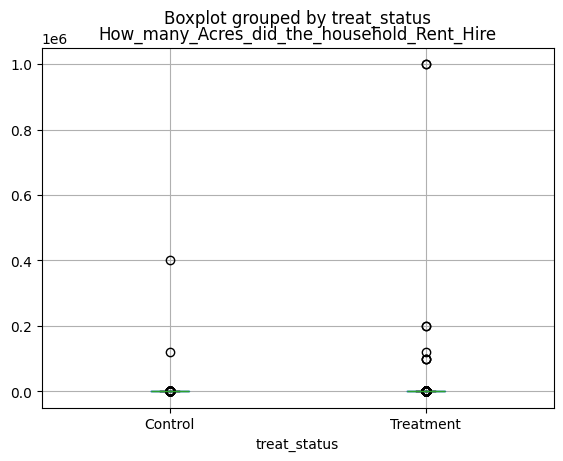

In [146]:
import matplotlib.pyplot as plt
df.boxplot(column='How_many_Acres_did_the_household_Rent_Hire', by='treat_status')
plt.show()

In [157]:
def remove_outliers_iqr(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return group[(group >= lower) & (group <= upper)]

pd.DataFrame(df.groupby('treat_status')['How_many_Acres_did_the_household_Rent_Hire'].apply(remove_outliers_iqr).groupby(level=0).mean())

,How_many_Acres_did_the_household_Rent_Hire
treat_status,
Control,0.66550866
Treatment,0.75887675


In [150]:
### with outliers
df.groupby('treat_status')['How_many_Acres_did_the_household_Rent_Hire'].mean()

treat_status
Control      653.35721142
Treatment    984.03813524
Name: How_many_Acres_did_the_household_Rent_Hire, dtype: float64

- 1	Low
- 2	Moderate
- 3	High

In [158]:
pd.DataFrame(df.groupby('treat_status')['fertility_level_rented_land'].value_counts(normalize=True))

proportion
treat_status fertility_level_rented_land            
Control      2.0                          0.83688833
             1.0                          0.08908407
             3.0                          0.07402760
Treatment    2.0                          0.78250261
             3.0                          0.17811084
             1.0                          0.03938655

- 1	Crop Agriculture
- 2	Livestock
- 3	Sub renting for a profit
- 97	Others,Specify

In [68]:
df.groupby('treat_status')['Rent_Paid_Per_Season'].mean() * adj_factor

treat_status
Control      39.12976056
Treatment    48.62077713
Name: Rent_Paid_Per_Season, dtype: float64

In [136]:
df.groupby('treat_status')[['purpose_land_rented_1', 'purpose_land_rented_2', 'purpose_land_rented_3', 'purpose_land_rented_97']].mean().T

treat_status,Control,Treatment
purpose_land_rented_1,0.98745295,0.99233182
purpose_land_rented_2,0.01380176,0.01219937
purpose_land_rented_3,0.00125471,0.00243987
purpose_land_rented_97,0.00376412,0.00104566


In [130]:
df.groupby('treat_status')['purpose_land_rented_1'].mean()

treat_status
Control      0.98745295
Treatment    0.99233182
Name: purpose_land_rented_1, dtype: float64

In [127]:
df.groupby('treat_status')['purpose_land_rented_2'].mean()

treat_status
Control      0.01380176
Treatment    0.01219937
Name: purpose_land_rented_2, dtype: float64

In [128]:
df.groupby('treat_status')['purpose_land_rented_3'].mean()

treat_status
Control      0.00125471
Treatment    0.00243987
Name: purpose_land_rented_3, dtype: float64

In [129]:
df.groupby('treat_status')['purpose_land_rented_97'].mean()

treat_status
Control      0.00376412
Treatment    0.00104566
Name: purpose_land_rented_97, dtype: float64

In [74]:
df[[
    'work_farm_non_member_pay_cash1', 'work_farm_non_member_pay_kind1',
    'work_farm_non_member_pay_cash2', 'work_farm_non_member_pay_kind2',
    'work_farm_non_member_pay_cash3', 'work_farm_non_member_pay_kind3',
]]

,work_farm_non_member_pay_cash1,work_farm_non_member_pay_kind1,work_farm_non_member_pay_cash2,work_farm_non_member_pay_kind2,work_farm_non_member_pay_cash3,work_farm_non_member_pay_kind3
0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,10000.0,NaN,10000.0,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
15469,NaN,NaN,NaN,NaN,NaN,NaN
15470,NaN,NaN,NaN,NaN,NaN,NaN
15471,NaN,NaN,NaN,NaN,NaN,NaN
15472,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
df["labour_spent"] = df[[
                        'work_farm_non_member_pay_cash1', 'work_farm_non_member_pay_kind1',
                        'work_farm_non_member_pay_cash2', 'work_farm_non_member_pay_kind2',
                        'work_farm_non_member_pay_cash3', 'work_farm_non_member_pay_kind3',
                    ]].sum(axis=1, min_count=1)

In [80]:
df['labour_spent'].value_counts(dropna=False)

labour_spent
NaN         11929
10000.0       525
5000.0        506
15000.0       279
14000.0       268
            ...  
270000.0        1
91000.0         1
37000.0         1
7006.0          1
12500.0         1
Name: count, Length: 153, dtype: int64

In [81]:
df['labour_spent'].mean()

17289.38815232722

In [103]:
df['has_labour'] = (df['labour_spent'] > 0).astype(int)
df.groupby('treat_status')['has_labour'].value_counts(normalize=True)

treat_status  has_labour
Control       0             0.85863192
              1             0.14136808
Treatment     0             0.75153176
              1             0.24846824
Name: proportion, dtype: float64

In [132]:
df[df['Agriculture Value (USD_Cons_rate)'] > 0].groupby('treat_status')['has_labour'].value_counts(normalize=True)

treat_status  has_labour
Control       0             0.85719041
              1             0.14280959
Treatment     0             0.75068826
              1             0.24931174
Name: proportion, dtype: float64

In [85]:
df[df['labour_spent'] >= 1000].groupby('treat_status')['labour_spent'].mean() * adj_factor

treat_status
Control      3.60897309
Treatment    3.67513984
Name: labour_spent, dtype: float64

In [86]:
df.groupby('treat_status')['labour_spent'].mean() * adj_factor

treat_status
Control      3.50354383
Treatment    3.64079682
Name: labour_spent, dtype: float64

In [88]:
## Purchased Land

In [156]:
## Additional Land

In [159]:
pd.DataFrame(df.groupby('treat_status')['land_bought'].value_counts(normalize=True))

proportion
treat_status land_bought            
Control      0            0.98501629
             1            0.01498371
Treatment    0            0.97250887
             1            0.02749113

In [160]:
pd.DataFrame(df.groupby('treat_status')['land_acreage_bought'].apply(remove_outliers_iqr).groupby(level=0).mean())

,land_acreage_bought
treat_status,
Control,0.33125000
Treatment,0.68586103


In [155]:
# with outliers
df.groupby('treat_status')['land_acreage_bought'].mean()

treat_status
Control      1.00923913
Treatment    0.76105572
Name: land_acreage_bought, dtype: float64

In [104]:
df.groupby('treat_status')['farming_inputs1_expenses'].count() 

treat_status
Control       450
Treatment    1999
Name: farming_inputs1_expenses, dtype: int64

In [98]:
df.groupby('treat_status')['farming_inputs1_expenses'].value_counts()

treat_status  farming_inputs1_expenses
Control       30000.0                     38
              20000.0                     36
              40000.0                     27
              10000.0                     26
              15000.0                     19
                                          ..
Treatment     31000.0                      9
              6500.0                       8
              41000.0                      8
              15800.0                      1
              20008.0                      1
Name: count, Length: 147, dtype: int64

In [39]:
grouped = df.groupby('treat_status')[farm_variables]

# 1. Counts (non-missing)
counts = grouped.count().T

# 2. Group sizes
cases = df.groupby('treat_status').size()

# 3. Percent cases (within group coverage)
percent_cases = counts.div(cases, axis=1) * 100

# 4. Percent responses (share across treatments)
percent_responses = counts.div(counts.sum(axis=1), axis=0) * 100

# 5. Adjusted means (costs)
adjusted_means = grouped.mean().T * (inflation_adjustment / 100) / const_rate_adjustment

# 6. Combine everything
result = pd.concat(
    [counts, percent_cases, percent_responses, adjusted_means],
    keys=['count','percent_cases','percent_responses','adjusted_mean'],
    axis=1
)
result

count           percent_cases               \
treat_status                 Control Treatment       Control    Treatment   
farming_inputs1_expenses         450      1999   14.65798046  16.11576911   
farming_inputs2_expenses         331      1943   10.78175896  15.66430184   
farming_inputs3_expenses          24       264    0.78175896   2.12834569   
farming_inputs4_expenses         103       394    3.35504886   3.17639471   
farming_inputs5_expenses         145       419    4.72312704   3.37794260   
farming_inputs6_expenses          13       177    0.42345277   1.42695905   
farming_inputs7_expenses          96       187    3.12703583   1.50757820   
farming_inputs8_expenses           0        29    0.00000000   0.23379555   
farming_inputs9_expenses         135      1039    4.39739414   8.37633022   
farming_inputs10_expenses        152      1237    4.95114007   9.97258949   
farming_inputsother_expenses       3        13    0.09771987   0.10480490   

                             percent_responses               adjusted_mean  \
treat_status                           Control     Treatment       Control   
farming_inputs1_expenses           18.37484688   81.62515312    5.85482685   
farming_inputs2_expenses           14.55584872   85.44415128    5.31651498   
farming_inputs3_expenses            8.33333333   91.66666667    2.93416667   
farming_inputs4_expenses           20.72434608   79.27565392    4.94657362   
farming_inputs5_expenses           25.70921986   74.29078014    6.66330460   
farming_inputs6_expenses            6.84210526   93.15789474    3.57097756   
farming_inputs7_expenses           33.92226148   66.07773852    4.93066623   
farming_inputs8_expenses            0.00000000  100.00000000           NaN   
farming_inputs9_expenses           11.49914821   88.50085179    6.07946914   
farming_inputs10_expenses          10.94312455   89.05687545    2.29741941   
farming_inputsother_expenses       18.75000000   81.25000000    1.39722222   

                                          
treat_status                   Treatment  
farming_inputs1_expenses      4.37989410  
farming_inputs2_expenses      6.61760184  
farming_inputs3_expenses      3.26838857  
farming_inputs4_expenses      4.43768771  
farming_inputs5_expenses      5.58872216  
farming_inputs6_expenses      2.30423258  
farming_inputs7_expenses      4.06053699  
farming_inputs8_expenses      5.55757184  
farming_inputs9_expenses      5.26768243  
farming_inputs10_expenses     2.31094004  
farming_inputsother_expenses  1.62024038

In [106]:
df['farming_inputs1_expenses']

0            NaN
1            NaN
2            NaN
3        15000.0
4            NaN
          ...   
15469        NaN
15470        NaN
15471        NaN
15472        NaN
15473        NaN
Name: farming_inputs1_expenses, Length: 15474, dtype: float64

In [107]:
df.groupby('treat_status')['farming_inputs1_expenses'].mean() * adj_factor

treat_status
Control      5.85482685
Treatment    4.37989410
Name: farming_inputs1_expenses, dtype: float64

In [111]:
rtv = df[df['treat_status'] == "Treatment"]
peer = df[df['treat_status'] == "Control"]

In [113]:
rtv['farming_inputs1_expenses'].mean() * adj_factor

4.379894097882275

In [116]:
rtv['farming_inputs1_expenses'].count() / len(rtv)

0.1611576910673976

In [108]:
df.groupby('treat_status')['farming_inputs1_expenses'].count()

treat_status
Control       450
Treatment    1999
Name: farming_inputs1_expenses, dtype: int64

In [118]:
df.groupby('treat_status')[farm_variables].count().T

treat_status,Control,Treatment
farming_inputs1_expenses,450,1999
farming_inputs2_expenses,331,1943
farming_inputs3_expenses,24,264
farming_inputs4_expenses,103,394
farming_inputs5_expenses,145,419
farming_inputs6_expenses,13,177
farming_inputs7_expenses,96,187
farming_inputs8_expenses,0,29
farming_inputs9_expenses,135,1039
farming_inputs10_expenses,152,1237


In [119]:
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

In [120]:
results = []

for var in farm_variables:
    x = df[df['treat_status']=="Treatment"][var].dropna()
    y = df[df['treat_status']=="Control"][var].dropna()

    if df[var].nunique() == 2:  # binary variable
        count = [x.sum(), y.sum()]
        nobs = [len(x), len(y)]
        stat, pval = proportions_ztest(count, nobs)
        test = "Proportion z-test"
    else:  # continuous
        stat, pval = ttest_ind(x, y, equal_var=False)  # Welch's t-test
        test = "Welch's t-test"

    results.append({"Variable": var, "Test": test, "p-value": pval})

results_df = pd.DataFrame(results)
print(results_df)

/Users/rtv-lpt-127/.pyenv/versions/3.10.9/envs/hands/lib/python3.10/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


                        Variable            Test     p-value
0       farming_inputs1_expenses  Welch's t-test  0.00003326
1       farming_inputs2_expenses  Welch's t-test  0.00000002
2       farming_inputs3_expenses  Welch's t-test  0.37842060
3       farming_inputs4_expenses  Welch's t-test  0.19465811
4       farming_inputs5_expenses  Welch's t-test  0.01567118
5       farming_inputs6_expenses  Welch's t-test  0.21207623
6       farming_inputs7_expenses  Welch's t-test  0.07407759
7       farming_inputs8_expenses  Welch's t-test         NaN
8       farming_inputs9_expenses  Welch's t-test  0.01868672
9      farming_inputs10_expenses  Welch's t-test  0.91097297
10  farming_inputsother_expenses  Welch's t-test  0.48202314


In [11]:
(df.groupby('treat_status')[farm_variables]
          .mean() * (inflation_adjustment / 100) / const_rate_adjustment).transpose()

treat_status,Control,Treatment
farming_inputs1_expenses,5.85482685,4.37989410
farming_inputs2_expenses,5.31651498,6.61760184
farming_inputs3_expenses,2.93416667,3.26838857
farming_inputs4_expenses,4.94657362,4.43768771
farming_inputs5_expenses,6.66330460,5.58872216
farming_inputs6_expenses,3.57097756,2.30423258
farming_inputs7_expenses,4.93066623,4.06053699
farming_inputs8_expenses,NaN,5.55757184
farming_inputs9_expenses,6.07946914,5.26768243
farming_inputs10_expenses,2.29741941,2.31094004


In [14]:
# Loop through each outcome variable
for outcome in farm_variables:
    treated = df[df['treat_status'] == 'Treatment'][outcome].dropna()
    control = df[df['treat_status'] == 'Control'][outcome].dropna()
    
    # Perform the t-test
    t_stat, p_value = stats.ttest_ind(treated, control)
    
    print(f"Outcome: {outcome}")
    print(f"T-statistic: {t_stat}, P-value: {p_value}")
    
    if p_value < 0.05:
        print(f"The treatment effect on {outcome} is statistically significant.\n")
    else:
        print(f"The treatment effect on {outcome} is not statistically significant.\n")


Outcome: farming_inputs1_expenses
T-statistic: -7.460765825436555, P-value: 1.1881607731817813e-13
The treatment effect on farming_inputs1_expenses is statistically significant.

Outcome: farming_inputs2_expenses
T-statistic: 5.089673133707455, P-value: 3.881152588977565e-07
The treatment effect on farming_inputs2_expenses is statistically significant.

Outcome: farming_inputs3_expenses
T-statistic: 0.879983329408291, P-value: 0.37960715410308365
The treatment effect on farming_inputs3_expenses is not statistically significant.

Outcome: farming_inputs4_expenses
T-statistic: -1.7353877379525038, P-value: 0.08329449963287955
The treatment effect on farming_inputs4_expenses is not statistically significant.

Outcome: farming_inputs5_expenses
T-statistic: -3.0616316329922144, P-value: 0.0023065731845232397
The treatment effect on farming_inputs5_expenses is statistically significant.

Outcome: farming_inputs6_expenses
T-statistic: -3.015752407183276, P-value: 0.00291786867569416
The treat

/Users/rtv-lpt-127/.pyenv/versions/3.10.9/envs/hands/lib/python3.10/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


Outcome: farming_inputs8_expenses
T-statistic: nan, P-value: nan
The treatment effect on farming_inputs8_expenses is not statistically significant.

Outcome: farming_inputs9_expenses
T-statistic: -2.964837664557376, P-value: 0.003089696605028504
The treatment effect on farming_inputs9_expenses is statistically significant.

Outcome: farming_inputs10_expenses
T-statistic: 0.13547292064045116, P-value: 0.8922576306123069
The treatment effect on farming_inputs10_expenses is not statistically significant.

Outcome: farming_inputsother_expenses
T-statistic: 0.42445546582083266, P-value: 0.6776840552562233
The treatment effect on farming_inputsother_expenses is not statistically significant.



- (***)   Significant 99%   0.010000000000000009, 

- (**)    Significant 95%    0.050000000000000044

- (*)     Significant 90%    0.09999999999999998

# Impact

In [204]:
df.groupby('treat_status')['HH Income (USD_Cons_rate)'].mean()

treat_status
Control      276.79512847
Treatment    475.93307147
Name: HH Income (USD_Cons_rate), dtype: float64

In [102]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import re

In [161]:
label_map = {
    "Program Value (USD_Cons_rate)": "Annual Program value",
    "HH Income +  HH Production (USD_Cons_rate)": "Household Income And Production",
    "HH Income (USD_Cons_rate)": "Household Income",
    "Agriculture Value (USD_Cons_rate)": "Annual Agriculture Value",
    "Livestock Asset Value (USD_Cons_rate)": "Livestock Assets"
}

In [162]:
def calculate_treatment_effects_abstract(df, outcome_vars):
    results = {}
    for var in outcome_vars:
        # Use Q() to quote variable names with problematic characters
        formula = f"Q('{var}') ~ C(group)"
        model = ols(formula, data=df).fit()
        coef = model.params['C(group)[T.Treatment]']
        se = model.bse['C(group)[T.Treatment]']
        ci_lower, ci_upper = model.conf_int().loc['C(group)[T.Treatment]']
        t_stat = model.tvalues['C(group)[T.Treatment]']
        p_value = model.pvalues['C(group)[T.Treatment]']
        
        results[label_map.get(var)] = {
            'impact (effect size)': coef,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'se': se,
            't_stat': abs(t_stat),
            'p_value': p_value
        }
    return model, results

In [163]:
income_streams = [
        "Program Value (USD_Cons_rate)", "HH Income +  HH Production (USD_Cons_rate)", "HH Income (USD_Cons_rate)",
        "Agriculture Value (USD_Cons_rate)", "Livestock Asset Value (USD_Cons_rate)",  
        ]

# Create impact_df and convert to daily values in one step
impact_df = df[["group"] + income_streams].copy()
# impact_df[income_streams] = impact_df[income_streams] / 365

impact_df.head()

,group,Program Value (USD_Cons_rate),HH Income + HH Production (USD_Cons_rate),HH Income (USD_Cons_rate),Agriculture Value (USD_Cons_rate),Livestock Asset Value (USD_Cons_rate)
0,Treatment,242.487917,217.337917,121.977500,217.337917,25.150000
1,Treatment,260.931250,260.931250,85.929167,187.577083,0.000000
2,Treatment,277.697917,130.989583,130.989583,0.000000,146.708333
3,Treatment,286.500417,286.500417,214.403750,183.804583,0.000000
4,Treatment,290.272917,290.272917,38.772917,264.075000,0.000000


In [164]:
model, results = calculate_treatment_effects_abstract(impact_df, income_streams)

In [165]:
print(model.summary())

                                        OLS Regression Results                                        
Dep. Variable:     Q('Livestock Asset Value (USD_Cons_rate)')   R-squared:                       0.010
Model:                                                    OLS   Adj. R-squared:                  0.010
Method:                                         Least Squares   F-statistic:                     151.5
Date:                                        Wed, 24 Sep 2025   Prob (F-statistic):           1.20e-34
Time:                                                16:27:56   Log-Likelihood:            -1.0337e+05
No. Observations:                                       15474   AIC:                         2.067e+05
Df Residuals:                                           15472   BIC:                         2.068e+05
Df Model:                                                   1                                         
Covariance Type:                                    nonrobust            

In [166]:
pd.DataFrame(results).T

,impact (effect size),ci_lower,ci_upper,se,t_stat,p_value
Annual Program value,386.103676,369.928895,402.278457,8.251945,46.789413,0.000000e+00
Household Income And Production,338.287085,324.959749,351.614421,6.799254,49.753557,0.000000e+00
Household Income,199.137943,188.565463,209.710423,5.393800,36.919788,4.844601e-286
Annual Agriculture Value,336.990106,325.713717,348.266495,5.752915,58.577277,0.000000e+00
Livestock Assets,47.816592,40.201284,55.431899,3.885128,12.307597,1.197370e-34


In [167]:
model.params

Intercept                116.388861
C(group)[T.Treatment]     47.816592
dtype: float64

In [168]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_forest(results, title="Treatment Effects"):
    df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Outcome'})
    df = df.sort_values("impact (effect size)")  # sort by effect size

    plt.figure(figsize=(8, len(df) * 0.6))
    
    # Plot CI lines
    plt.hlines(y=df['Outcome'], xmin=df['ci_lower'], xmax=df['ci_upper'], color='gray')
    
    # Plot point estimates
    plt.plot(df['impact (effect size)'], df['Outcome'], 'o', color='black')
    
    # Add vertical reference line
    plt.axvline(x=0, color='red', linestyle='--')
    
    plt.xlabel("Treatment Effect")
    plt.title(title)
    plt.tight_layout()
    plt.show()

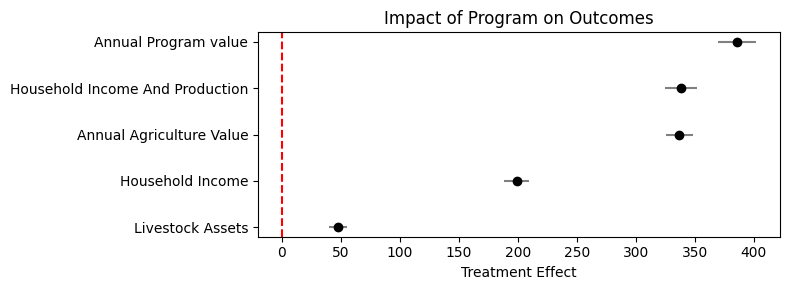

In [169]:
plot_forest(results, title="Impact of Program on Outcomes")

In [170]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols

def calculate_treatment_effects_with_std(df, outcome_vars):
    results = {}
    for var in outcome_vars:
        formula = f"Q('{var}') ~ C(group)"
        model = ols(formula, data=df).fit()
        coef = model.params['C(group)[T.Treatment]']
        se = model.bse['C(group)[T.Treatment]']
        ci_lower, ci_upper = model.conf_int().loc['C(group)[T.Treatment]']
        t_stat = model.tvalues['C(group)[T.Treatment]']
        p_value = model.pvalues['C(group)[T.Treatment]']
        
        # Standardized effect (Cohen's d)
        treatment = df[df['group'] == 'Treatment'][var]
        control = df[df['group'] == 'Control'][var]
        n1, n2 = len(treatment), len(control)
        pooled_sd = np.sqrt(((n1-1)*treatment.var() + (n2-1)*control.var()) / (n1+n2-2))
        cohen_d = coef / pooled_sd
        ci_lower_d, ci_upper_d = ci_lower / pooled_sd, ci_upper / pooled_sd
        
        results[label_map.get(var)] = {
            'impact': coef,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'se': se,
            't_stat': abs(t_stat),
            'p_value': p_value,
            'standardized_effect': cohen_d,
            'ci_lower_d': ci_lower_d,
            'ci_upper_d': ci_upper_d
        }
    return model, results

In [199]:
model_1, results_1 = calculate_treatment_effects_with_std(impact_df, income_streams)

In [200]:
pd.DataFrame(results_1).T

,impact,ci_lower,ci_upper,se,t_stat,p_value,standardized_effect,ci_lower_d,ci_upper_d
Annual Program value,386.10367643,369.92889543,402.27845743,8.25194534,46.78941277,0.00000000e+00,0.94318921,0.90367682,0.98270160
Household Income And Production,338.28708485,324.95974881,351.61442090,6.79925425,49.75355711,0.00000000e+00,1.00294095,0.96342856,1.04245334
Household Income,199.13794300,188.56546271,209.71042329,5.39379973,36.91978807,4.84460087e-286,0.74423558,0.70472319,0.78374797
Annual Agriculture Value,336.99010597,325.71371721,348.26649473,5.75291521,58.57727671,0.00000000e+00,1.18081105,1.14129866,1.22032344
Livestock Assets,47.81659157,40.20128449,55.43189865,3.88512820,12.30759686,1.19736973e-34,0.24809870,0.20858631,0.28761109


In [173]:
def plot_forest_dual(results, title="Treatment Effects (Raw vs Standardized)"):
    df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Outcome'})
    df = df.sort_values("impact")

    fig, axes = plt.subplots(1, 2, figsize=(12, len(df) * 0.6), sharey=True)

    # Left: raw effects
    axes[0].hlines(y=df['Outcome'], xmin=df['ci_lower'], xmax=df['ci_upper'], color='gray')
    axes[0].plot(df['impact'], df['Outcome'], 'o', color='black')
    axes[0].axvline(x=0, color='red', linestyle='--')
    axes[0].set_xlabel("Treatment Effect (raw units)")

    # Right: standardized effects
    axes[1].hlines(y=df['Outcome'], xmin=df['ci_lower_d'], xmax=df['ci_upper_d'], color='gray')
    axes[1].plot(df['standardized_effect'], df['Outcome'], 'o', color='black')
    axes[1].axvline(x=0, color='red', linestyle='--')
    axes[1].set_xlabel("Standardized Effect (Cohen's d)")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


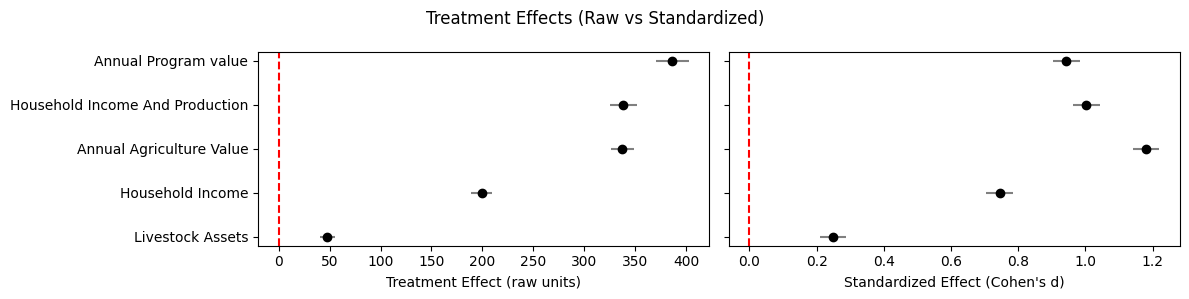

In [174]:
plot_forest_dual(results_1)

In [193]:
from matplotlib import rcParams
import matplotlib.pyplot as plt
import pandas as pd

# Set consistent styling
rcParams['font.family'] = 'monospace'
rcParams['font.size'] = 14

def plot_forest_dual(results, title="Treatment Effects (Raw vs Standardized)"):
    df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Outcome'})
    df = df.sort_values("impact")
    
    # Create figure with better proportions
    height = max(10, len(df) * 1.2)  # More space per outcome
    fig, axes = plt.subplots(1, 2, figsize=(20, height), 
                           sharey=True, dpi=300)  # Lower DPI for better display
    
    # Left panel: raw effects
    axes[0].hlines(y=range(len(df)), xmin=df['ci_lower'], xmax=df['ci_upper'], 
                   color='gray', linewidth=3, alpha=0.8)
    axes[0].plot(df['impact'], range(len(df)), 'o', color='black', markersize=10)
    axes[0].axvline(x=0, color='green', linestyle='--', linewidth=2, label='Null Effect')
    axes[0].set_xlabel("Treatment Effect (raw units)", fontsize=18, fontweight='bold')
    axes[0].set_yticks(range(len(df)))
    axes[0].set_yticklabels(df['Outcome'], fontsize=14)
    axes[0].grid(axis='x', linestyle='--', alpha=0.4)
    axes[0].legend(fontsize=14, loc='lower right')
    axes[0].tick_params(axis='x', which='major', labelsize=14)
    
    # Right panel: standardized effects
    axes[1].hlines(y=range(len(df)), xmin=df['ci_lower_d'], xmax=df['ci_upper_d'], 
                   color='gray', linewidth=3, alpha=0.8)
    axes[1].plot(df['standardized_effect'], range(len(df)), 'o', color='black', markersize=10)
    axes[1].axvline(x=0, color='green', linestyle='--', linewidth=2, label='Null Effect')
    axes[1].set_xlabel("Standardized Effect (Cohen's d)", fontsize=18, fontweight='bold')
    axes[1].grid(axis='x', linestyle='--', alpha=0.4)
    axes[1].legend(fontsize=14, loc='lower right')
    axes[1].tick_params(axis='x', which='major', labelsize=14)
    
    # Main title with better spacing
    fig.suptitle(title, fontsize=22, fontweight='bold', y=0.98)
    
    # Add more space between panels
    plt.subplots_adjust(wspace=0.3)
    
    # Optimize layout and save
    plt.tight_layout()
    # plt.savefig("forest_plot_dual.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_forest_single(results, effect_type="raw", title=None):
    """Create a single forest plot for either raw or standardized effects"""
    df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Outcome'})
    df = df.sort_values("impact")
    
    # Create figure with better proportions
    height = max(10, len(df) * 1.2)
    fig, ax = plt.subplots(figsize=(14, height), dpi=300)
    
    if effect_type == "raw":
        ax.hlines(y=range(len(df)), xmin=df['ci_lower'], xmax=df['ci_upper'], 
                  color='gray', linewidth=3, alpha=0.8)
        ax.plot(df['impact'], range(len(df)), 'o', color='black', markersize=10)
        ax.set_xlabel("Treatment Effect (raw units)", fontsize=18, fontweight='bold')
        default_title = "Treatment Effects (Raw Units)"
    else:  # standardized
        ax.hlines(y=range(len(df)), xmin=df['ci_lower_d'], xmax=df['ci_upper_d'], 
                  color='gray', linewidth=3, alpha=0.8)
        ax.plot(df['standardized_effect'], range(len(df)), 'o', color='black', markersize=10)
        ax.set_xlabel("Standardized Effect (Cohen's d)", fontsize=18, fontweight='bold')
        default_title = "Standardized Treatment Effects"
    
    # Common styling
    ax.axvline(x=0, color='green', linestyle='--', linewidth=2, label='Null Effect')
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df['Outcome'], fontsize=14)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.legend(fontsize=14, loc='lower right')
    ax.tick_params(axis='x', which='major', labelsize=14)
    ax.set_title(title or default_title, fontsize=22, fontweight='bold', pad=20)
    
    # Optimize layout and save
    plt.tight_layout()
    # plt.savefig(f"forest_plot_{effect_type}.png", dpi=300, bbox_inches='tight')
    plt.show()

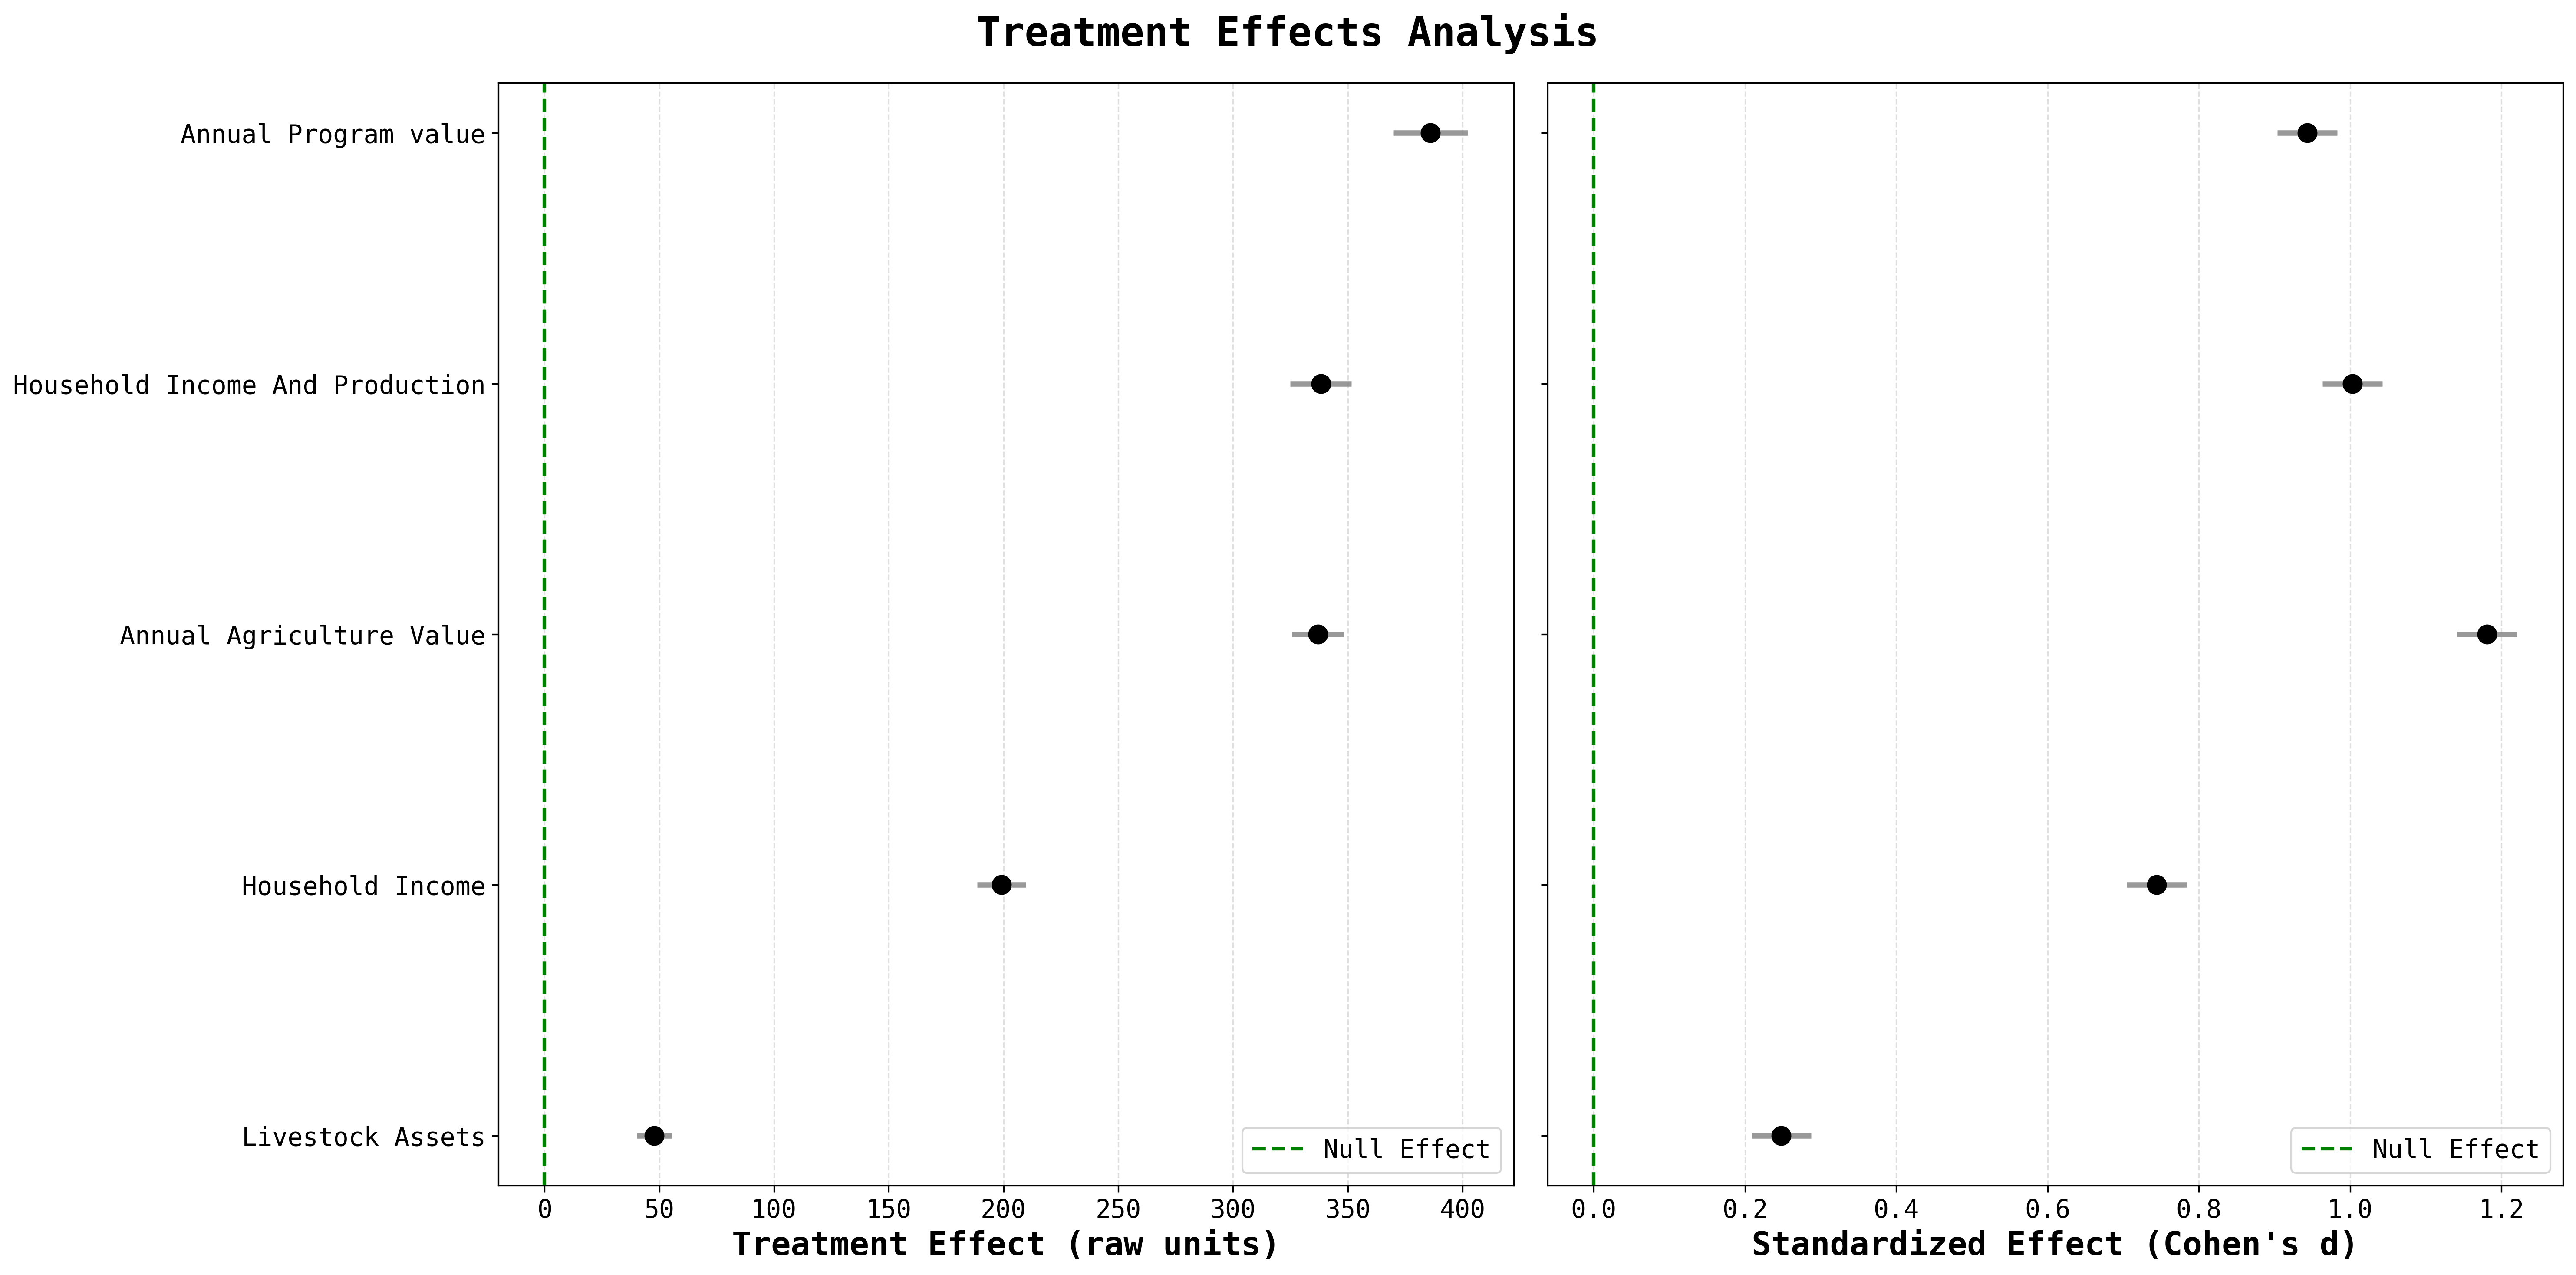

In [194]:
plot_forest_dual(results_1, title="Treatment Effects Analysis")

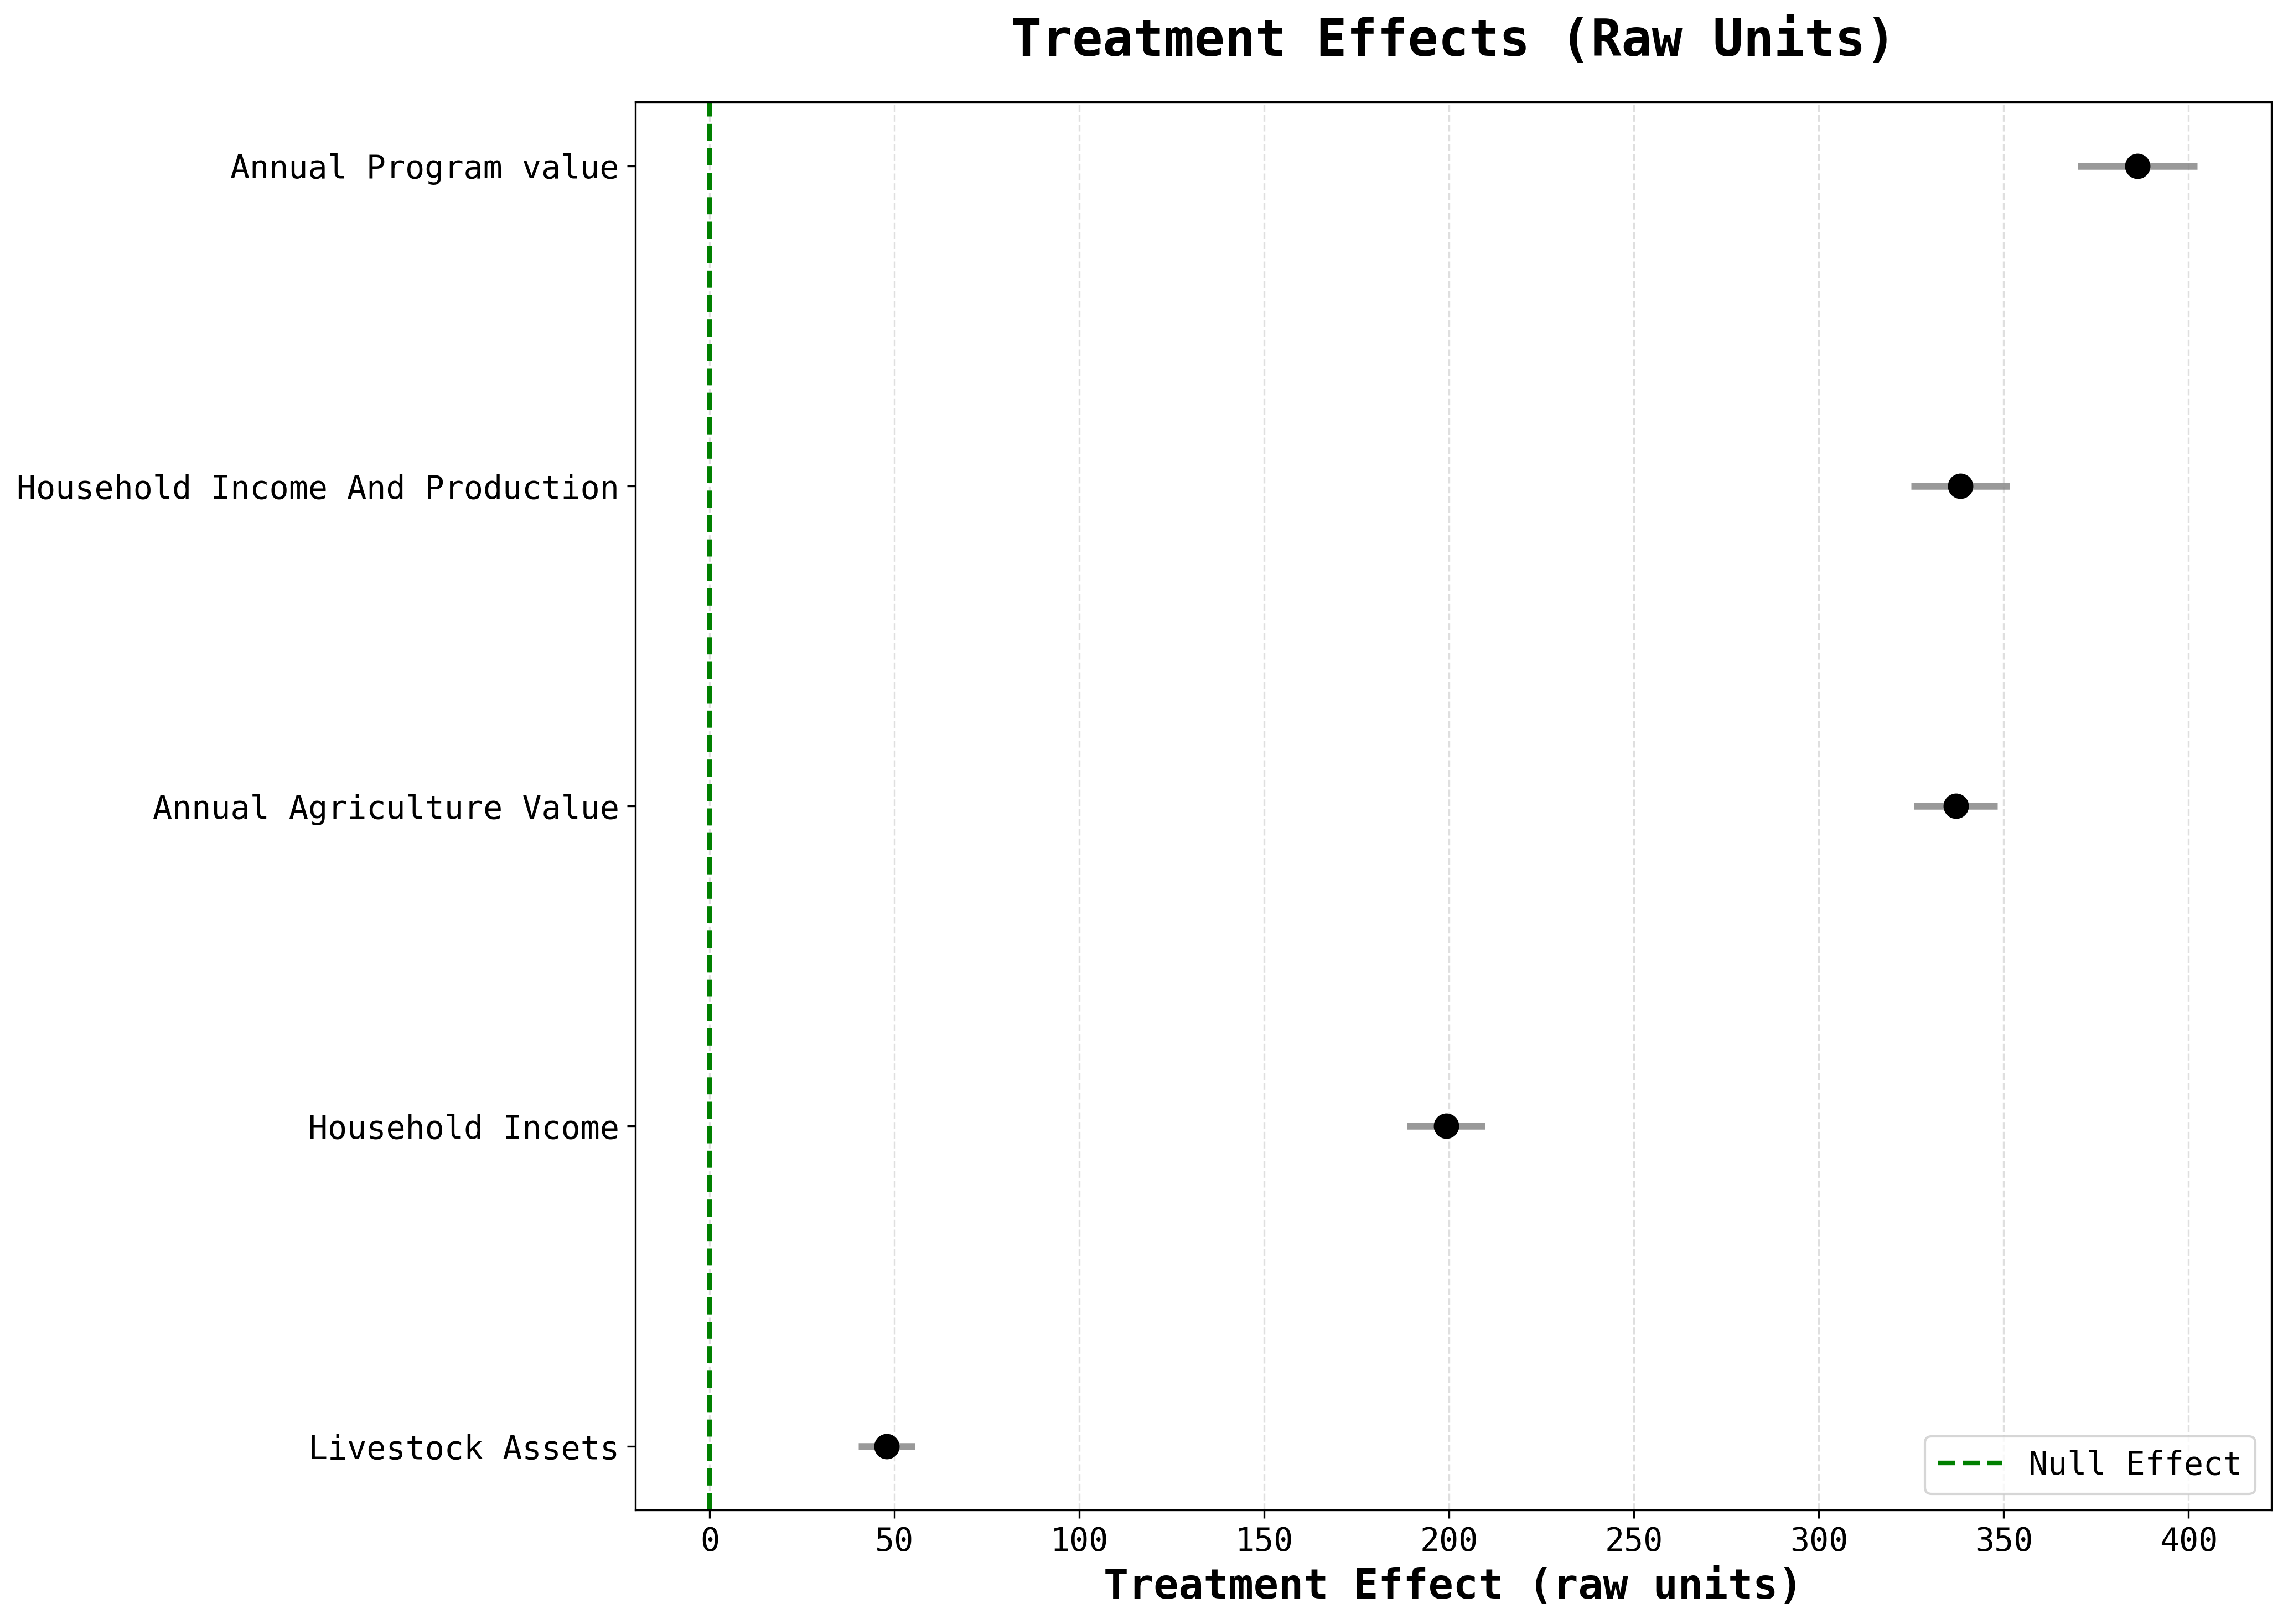

In [195]:
# For raw effects only
plot_forest_single(results_1, effect_type="raw")

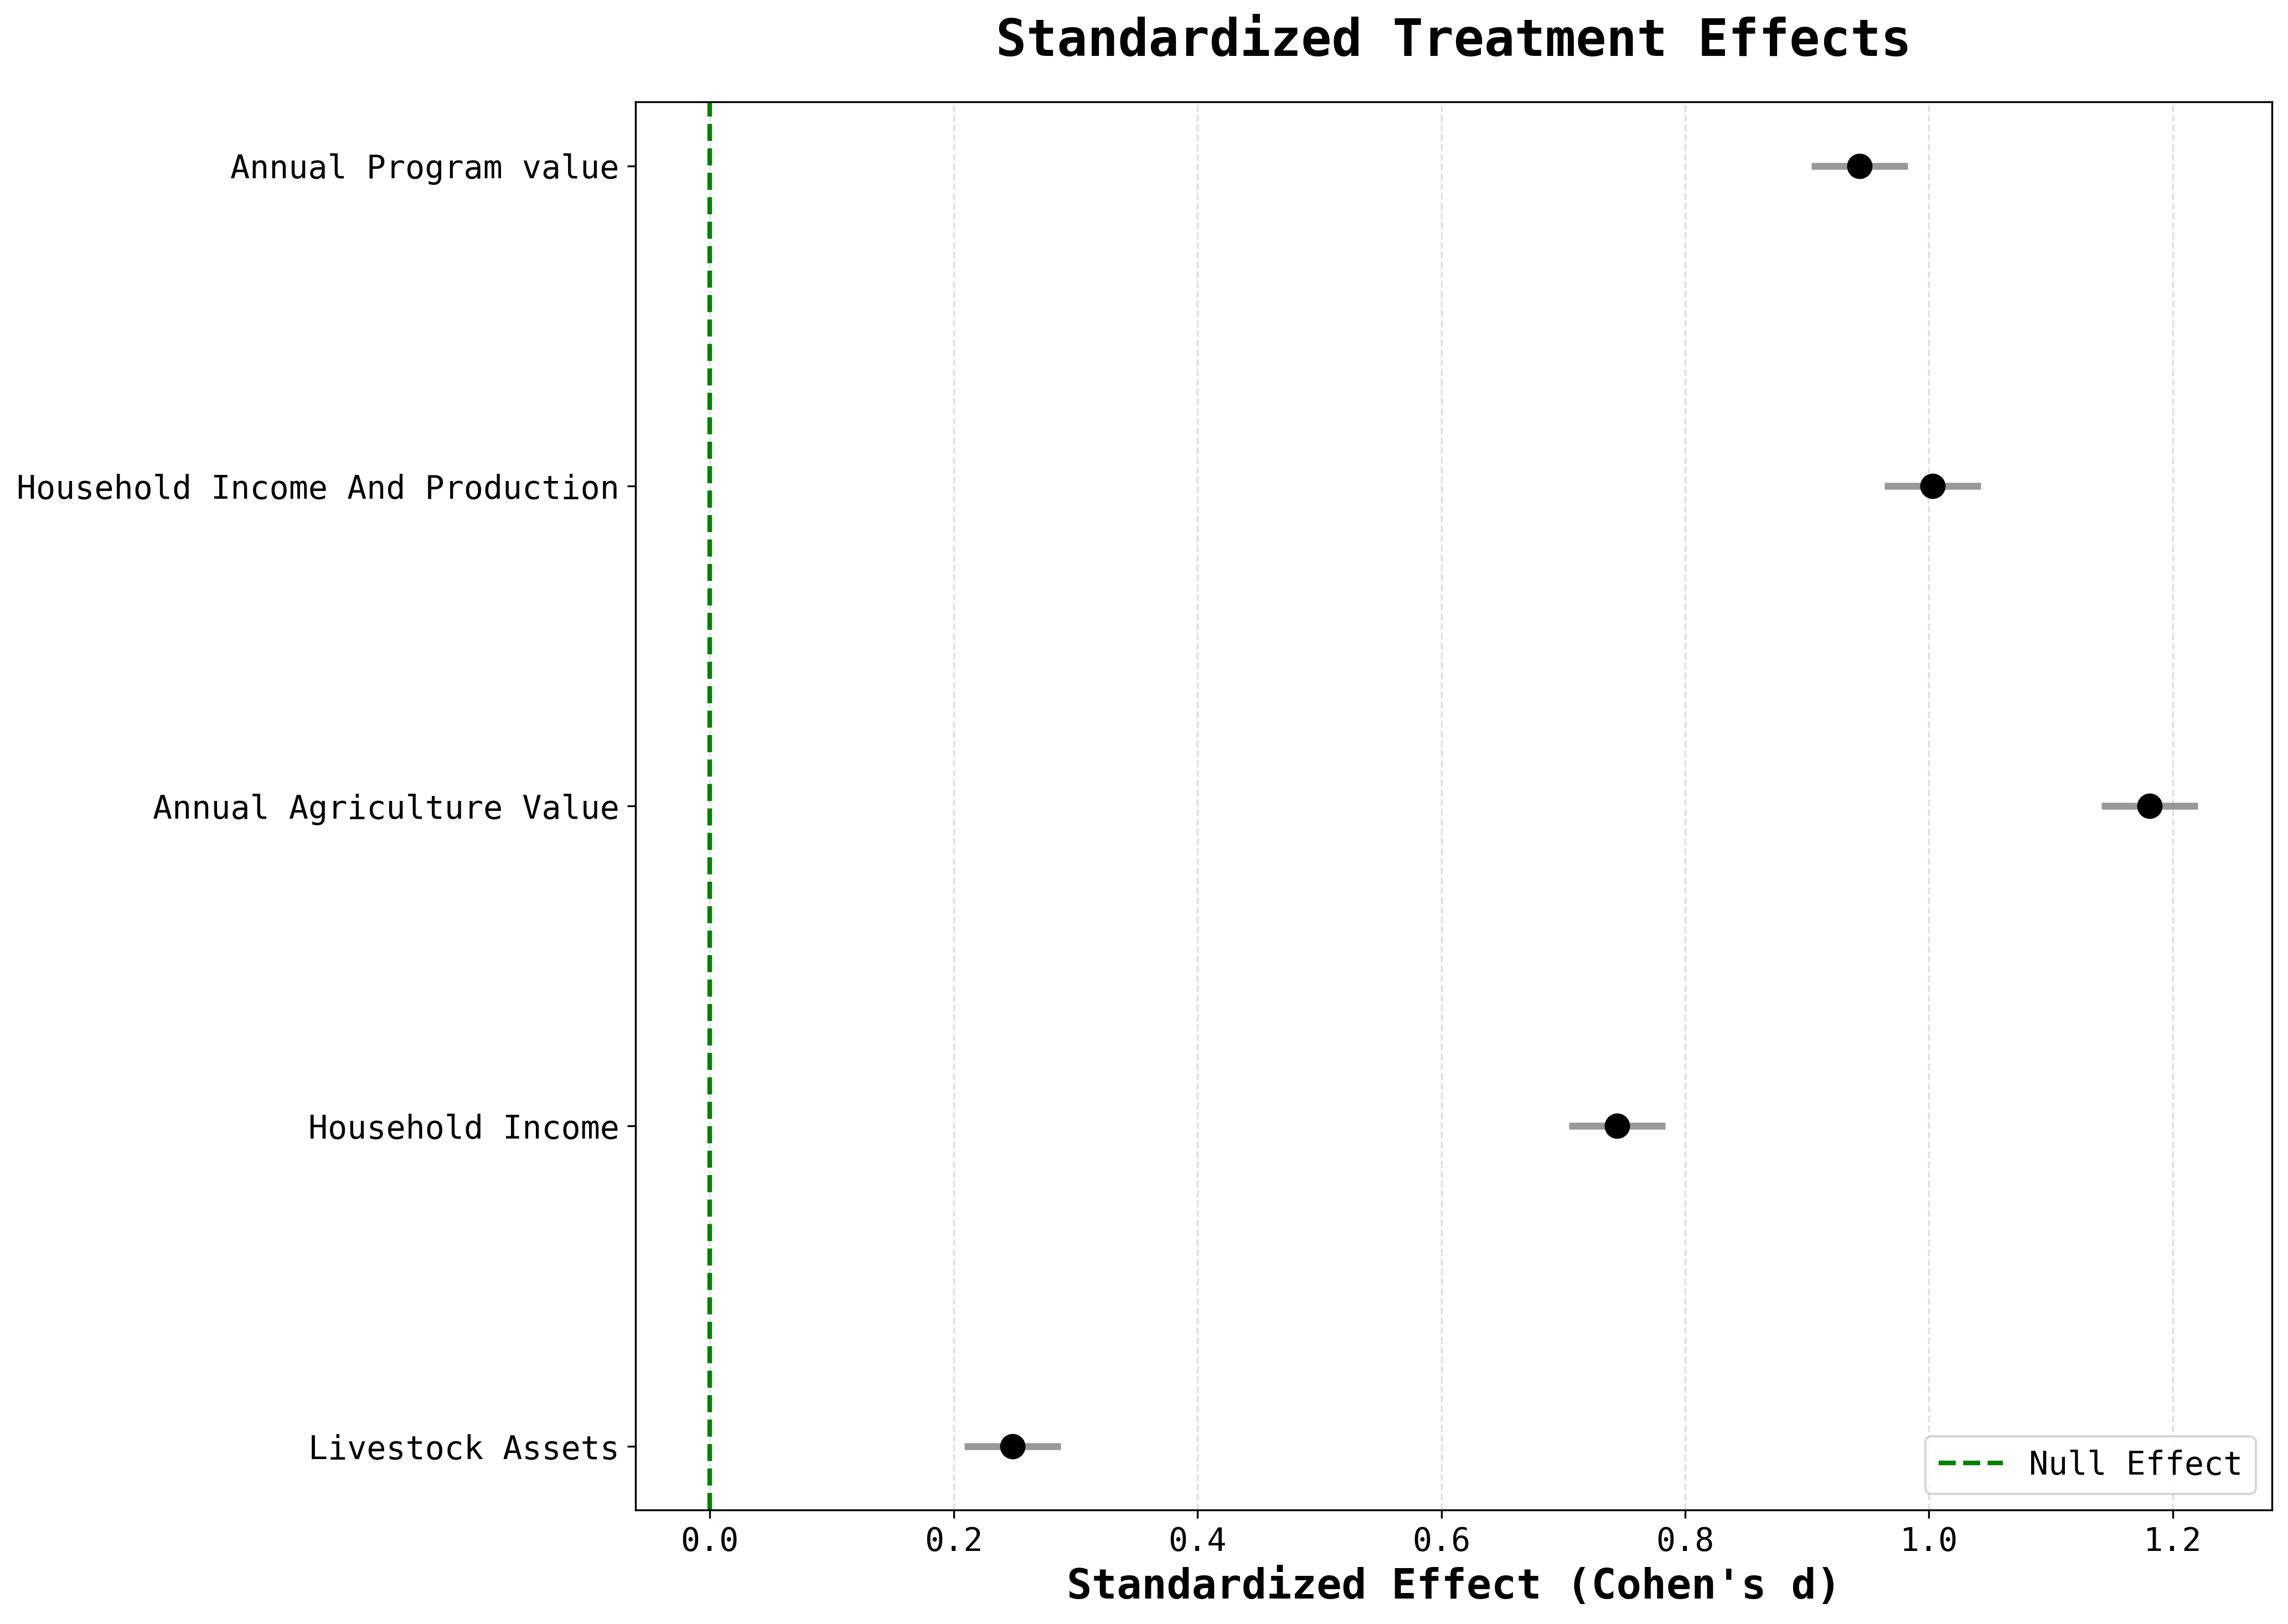

In [196]:
# For standardized effects only  
plot_forest_single(results_1, effect_type="standardized")

In [ ]:
# # With custom titles
# plot_forest_single(results_1, effect_type="raw", 
#                   title="Raw Treatment Effects on Key Outcomes")

In [181]:
# plot_forest_single(results, effect_type="standardized", 
#                   title="Effect Sizes (Cohen's d)")